# 25 DMOs -> fatigue

In [2]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOTransformer, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

In [3]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam, AdamW

config = ModelConfig(
    name="transformer_regression",
    model_type="Transformer",
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
    
    #not used
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
)
config.notes = "None"

transformer_config = {
    "input_features": 25,
    "d_model": 32,
    "nheads": 4,
    "num_layers": 1,
    "dim_feedforward": 4*32,
    "output_size": 1,
    "dropout": 0.1
}


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [9]:
dmo_data = dmo_data.mean(axis=2)

In [10]:
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)
dmo_data = dmo_data.unsqueeze(1)
dmo_labels = dmo_labels.flatten(start_dim=0, end_dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=1)
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([1400, 1, 25])
torch.Size([1400, 1, 1])


In [11]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data, dmo_labels, batch_size=16, transforms=transforms)

In [12]:
model = DMOTransformer(**transformer_config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    device,
    verbose=True,
)

trainer.train_loop()
prediction, actual = trainer.test_loop()


Testing loss: 0.06433089946707089


In [13]:
print(prediction)
print(actual)

[tensor([[0.3274]]), tensor([[0.5972]]), tensor([[0.4571]]), tensor([[0.5770]]), tensor([[0.6085]]), tensor([[0.1984]]), tensor([[0.6072]]), tensor([[0.5903]]), tensor([[0.5587]]), tensor([[0.4507]]), tensor([[0.7010]]), tensor([[0.4665]]), tensor([[0.6865]]), tensor([[0.4593]]), tensor([[0.5936]]), tensor([[0.5120]]), tensor([[0.0672]]), tensor([[0.1000]]), tensor([[0.4298]]), tensor([[0.5291]]), tensor([[0.6165]]), tensor([[0.6382]]), tensor([[0.6682]]), tensor([[0.6610]]), tensor([[0.5591]]), tensor([[0.7359]]), tensor([[0.4478]]), tensor([[0.4822]]), tensor([[0.3026]]), tensor([[0.6061]]), tensor([[0.4514]]), tensor([[0.5173]]), tensor([[0.6516]]), tensor([[0.3036]]), tensor([[0.7425]]), tensor([[0.6755]]), tensor([[0.6241]]), tensor([[0.4905]]), tensor([[0.6027]]), tensor([[0.6042]]), tensor([[0.5961]]), tensor([[0.4655]]), tensor([[0.3455]]), tensor([[0.4825]]), tensor([[0.4698]]), tensor([[0.6389]]), tensor([[0.7247]]), tensor([[0.5115]]), tensor([[0.7306]]), tensor([[0.4242]]),

All metrics: {'accuracy': 0.2714285714285714, 'Mean Squared Error': 0.06522385776042938, 'Mean Absolute Error': 0.20873361825942993, 'R^2': -0.16415631771087646}


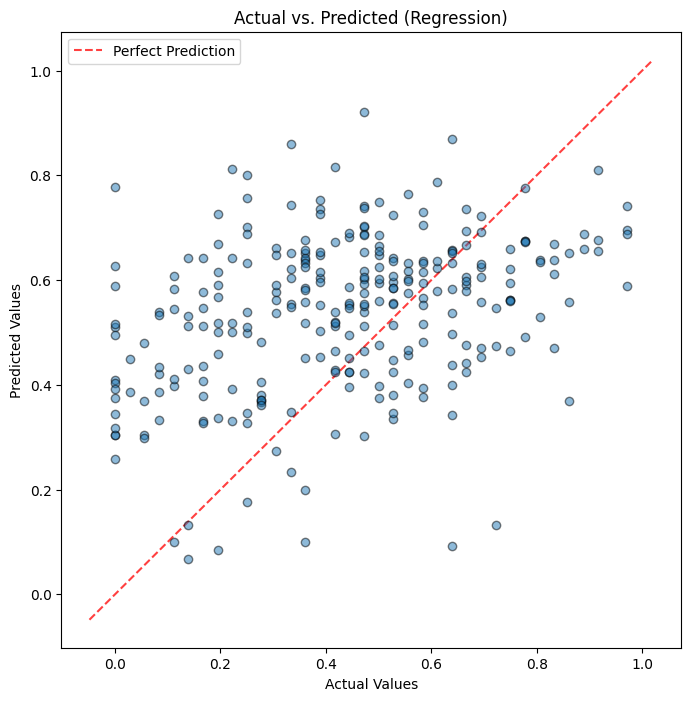

In [14]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()


In [15]:
# convert training and testing dataloader back to tensor
all_inputs_training = []

for a, b in training_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_training.append(a[p])

training_tensor = torch.stack(all_inputs_training)

all_inputs_testing = []

for a, b in testing_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_testing.append(a[p])

testing_tensor = torch.stack(all_inputs_testing)

In [16]:
print(training_tensor.shape)

torch.Size([1120, 1, 25])


In [17]:
# Have to wrap the model to format the output so shap can use it (bit silly tho)

from torch import nn

class LSTMWrapper(nn.Module):
    def __init__(self, model, device):
        super().__init__()
        self.model = model
        self.device = device

    def forward(self, input_data):
        data = input_data.to(device=self.device, dtype=torch.float32)
        output = self.model(data)
        
        if isinstance(output, tuple):
            output = output[0]

        output = output.squeeze(-1)

        return output

In [18]:
import shap
torch.backends.cudnn.enabled = False

device = torch.device("cpu")
model = model.to(device=device)
model_wrapper = LSTMWrapper(model, device)
model_wrapper.eval()


background_data = training_tensor[:].to(device=device)
data = testing_tensor[:].to(device=device)

explainer = shap.GradientExplainer(model_wrapper, background_data)
shap_values = explainer.shap_values(data)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
shap_values = shap_values.squeeze()
shap_values.shape

(280, 25)

/tmp/ipykernel_117000/2007217077.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)


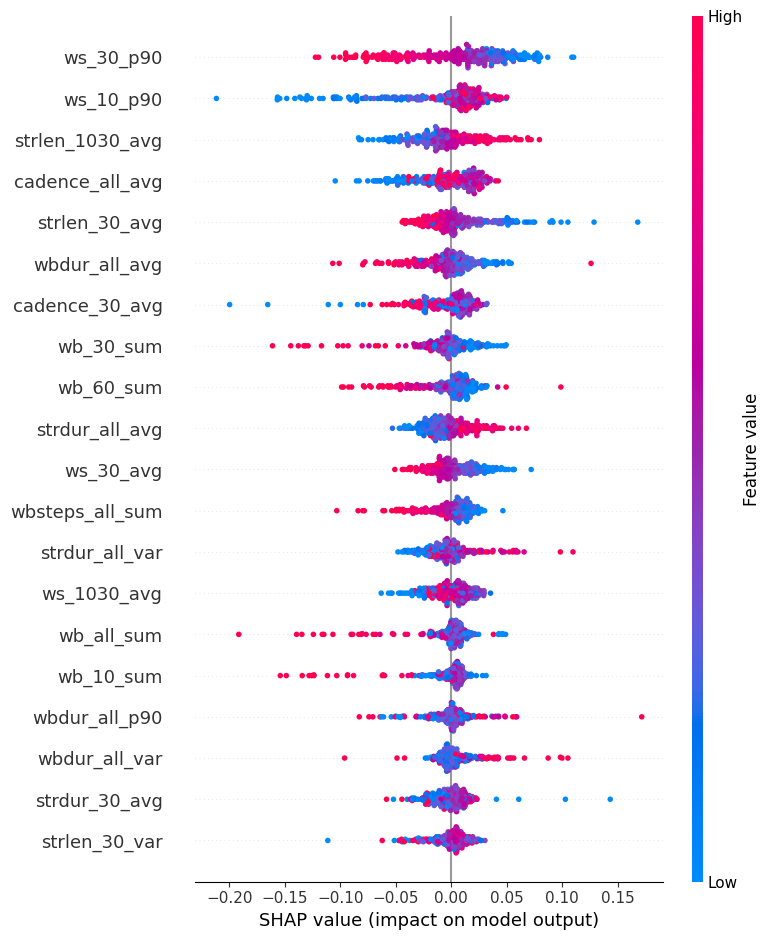

In [20]:
shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)